# Librerías

In [ ]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar

plt.rcParams["figure.figsize"] = (10,7) #tamaño de los gráficos: ancho x alto

# Métodos de punto fijo en **una** variable: ¿cuál es la idea y objetivo de estos métodos?
---

## Idea igual que antes:
### **Primero** definir una función que haga **UN SOLO PASO**.

### **Segundo** definir una función que aplique muchas veces el paso.
---

## Definir una función `paso_puntoFijo` que haga **UN SOLO PASO** del método de punto fijo

### ¿Qué tiene que recibir como entrada esta función? ¿Qué tiene que devolver?

In [ ]:
def paso_puntoFijo(x, func):
  x_sig = func(x)
  return x_sig

---
## Definir `metodo_puntoFijo_cant` que aplique el método de punto fijo una cantidad de veces fijada.
## Idea: aplicar `paso_puntoFijo` una cantidad fijada de veces.

### ¿Qué tiene que recibir como entrada esta función? ¿Qué tiene que devolver?

In [ ]:
def metodo_puntoFijo_cant(x0, func, cant_pasos):
  x = x0

  for i in range(0,cant_pasos,1):
    x_sig = paso_puntoFijo(x, func)
    x = x_sig
    # print("Paso:", i, "x:", x) #descomentar para ver x en cada paso

  return x

---
# Se desea aproximar una solución de la ecuación no lineal $2\sin(x)-x=0$


1. ### Proponer un método de punto fijo para aproximar una solución de la ecuación (incluido un intervalo inicial).
2. ### Encontrar un intervalo para que el método converja para cualquier valor inicial.
3. ### Determinar, **a priori** (en papel), la cantidad necesaria de pasos para aproximar a la solución con error menor que $10^{-8}$.
4. ### Correr el método la cantidad de pasos averiguada en el punto anterior e imprimir la aproximación de la solución.
1. ### ¿Cómo podría verificar que efectivamente la solución hallada por el método del punto fijo es una aproximación de la solución de la ecuación no lineal?

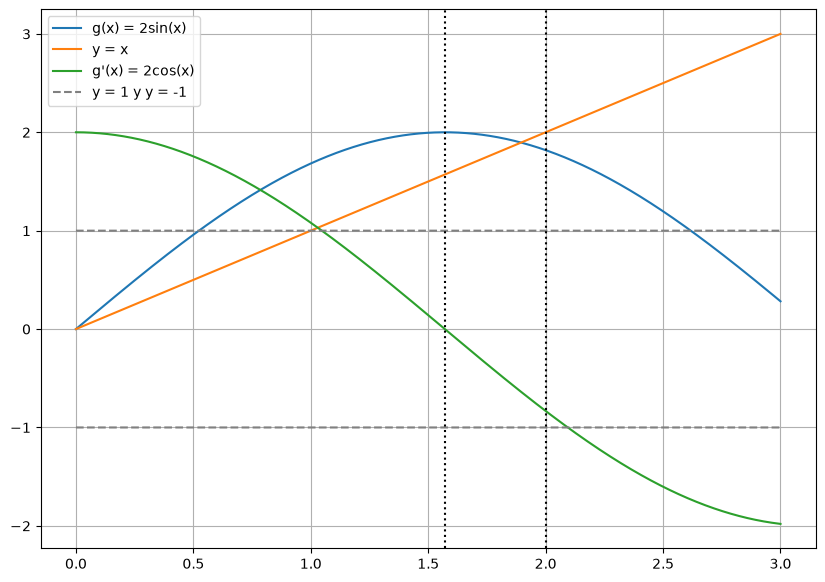

In [ ]:
# graficamos g y g' para elegir el intervalo
def g(x):
  y = 2*np.sin(x)
  return y

def dg(x):
  y = 2*np.cos(x)
  return y

vals_x = np.linspace(0, 3, 10000)

plt.plot(vals_x, g(vals_x), label="g(x) = 2sin(x)")
plt.plot(vals_x, vals_x, label="y = x") #donde corta a g están los puntos fijos
plt.plot(vals_x, dg(vals_x), label="g'(x) = 2cos(x)")
plt.plot(vals_x, np.ones(len(vals_x)), "--", color="gray", label="y = 1 y y = -1")
plt.plot(vals_x, -np.ones(len(vals_x)), "--", color="gray")
plt.axvline(np.pi/2, color="black", linestyle=":") #intervalo elegido [pi/2, 2]
plt.axvline(2, color="black", linestyle=":")
plt.legend()
plt.grid()

In [ ]:
# resolviendo 2 obtener un intervalo, mirando los gráficos de g y g' (hay muchas posibilidades, por supuesto)
# resolviendo 3 obtuve el n (mirar expresiones del error de las diapos de Mercedes)

# 1. 2sin(x)-x=0 es lo mismo que x = 2sin(x), entonces propongo g(x) = 2sin(x).
# 2. En I = [pi/2, 2]: g es decreciente, g(pi/2) = 2 y g(2) = 1.8186..., así que g(I) está contenido en I.
#    Además |g'(x)| = |2cos(x)| <= |2cos(2)| = 0.8322... = k < 1 en I. Entonces converge para cualquier x0 en I.
# 3. Error: |x_n - r| <= k**n * |x0 - r| <= k**n * (2 - pi/2). Busco el n para que eso sea menor a 10**(-8).

# definimos la función
def g(x):
  y = 2*np.sin(x)
  return y

# la cota del error que hice a mano, y busco el n con un while (como en Taylor)
k = abs(2*np.cos(2))
def cota_error(n):
  resultado = k**n * (2 - np.pi/2)
  return resultado

n = 0
while cota_error(n) >= 10**(-8):
  n = n + 1
print("Cantidad de pasos necesaria (a priori):", n)
print("")

# definimos x inicial y cantidad de pasos
x0 = 1.7
cant_pasos = n

# aplicamos punto fijo e imprimimos la aprox a la sol
x_final = metodo_puntoFijo_cant(x0, g, cant_pasos)

print("La aproximación luego de", cant_pasos, "pasos es:", x_final)

# verificamos que la aprox a la sol tiene sentido
print("Verifico que aproximo a un punto fijo:", abs( g(x_final) - x_final ) )
print("Verifico que aproximo a una solución de la ecuación:", 2*np.sin(x_final) - x_final )

Cantidad de pasos necesaria (a priori): 96

La aproximación luego de 96 pasos es: 1.8954942670339807
Verifico que aproximo a un punto fijo: 4.440892098500626e-16
Verifico que aproximo a una solución de la ecuación: 4.440892098500626e-16


---
# **Ejercicio:** el 16 de la P2.